In [1]:
import furuta_systems
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import furuta_params
import furuta_trajectory_gen
from IPython.display import display, Math
import scipy

# Überführung und Regelung in der stabilen Ruhelage

### Wie Sie anhand der Simulationsstudie mit der erarbeiteten Steuerung festgestellt haben, kommt es mit den Haftreibungen zu Abweichungen bei der Überführung.


## 3.11 Erweitern Sie Ihre Steuerung aus 3.9 um einen Zustandsregler zu einer 2-Freiheitsgraderegelung. Gehen Sie davon aus, dass Ihnen der gesamte Zustand als Messung zur Verfügung steht. Testen Sie den Regler simulativ für das in 3.10 beschriebene Szenario unter Berücksichtigung der Haftreibungen.

In [2]:
params_auslegung = furuta_params.FurutaParams()
params_auslegung.mu_H1 = 0.0
params_auslegung.mu_H2 = 0.0
operating_point = (0,0,0,0,0)
haft_reibung = True #legt fest ob die Haftreibung im nicht linearen Modell (simulation) existiert

params_sim = furuta_params.FurutaParams()
if not haft_reibung:
    params_sim.mu_H1 = 0.0
    params_sim.mu_H2 = 0.0

# Ausgang gleich Theta1 setzen um später b0 zu berechnen
cT = np.array([[1, 0, 0, 0]])

y0 = 0.0
yT = (140.0/360.0) * 2 * np.pi
t0 = 0
t1 = 2.5

x0 = [0.0, 0.0, 0.0, 0.0]
t_sim = np.linspace(0.0, 10.0, 10000)

#Regler Parameter (harmonischer Oszillator)
omega0_scaler = 1.0 #omega0 = max. eigenwert von A
D = -0.5
D_down = 1.01 * D

### Regler Verstärkung berechnen

In [3]:
A, b = furuta_systems.get_linear_furuta(params_auslegung, operating_point)
eigvals = np.linalg.eigvals(A)
omega0 = float(omega0_scaler * np.max(np.abs(eigvals)))

imag = np.sqrt(1.0 - D**2)
k_res = scipy.signal.place_poles(A, b, (D*omega0, D_down*omega0, omega0*(D+1j*imag), omega0*(D-1j*imag)))
k = k_res.gain_matrix

### Trajektorie berechnen

In [4]:
b0, b1, b2, b3 = furuta_systems.get_b_coefficients_furuta(cT, params_auslegung, operating_point)

eta0 = y0/b0
etaT = yT/b0

u_ref, x_ref = furuta_trajectory_gen.generate_trajectorys(eta0, etaT, t0, t1, params_auslegung, operating_point)

### Simulation:

In [5]:
non_linear_furuta_system = furuta_systems.get_non_linear_furuta_system(params_sim)

def simulation_system_2FHG(t, x):
    u = u_ref(t) -k @ (x - x_ref(t))
    return non_linear_furuta_system(t, x, u)

sol = solve_ivp(
    simulation_system_2FHG,
    (float(t_sim[0]), float(t_sim[-1])),
    x0,
    t_eval=t_sim,
    rtol=1e-6,
    atol=1e-9,
    max_step=1e-3,
)

### Plotten

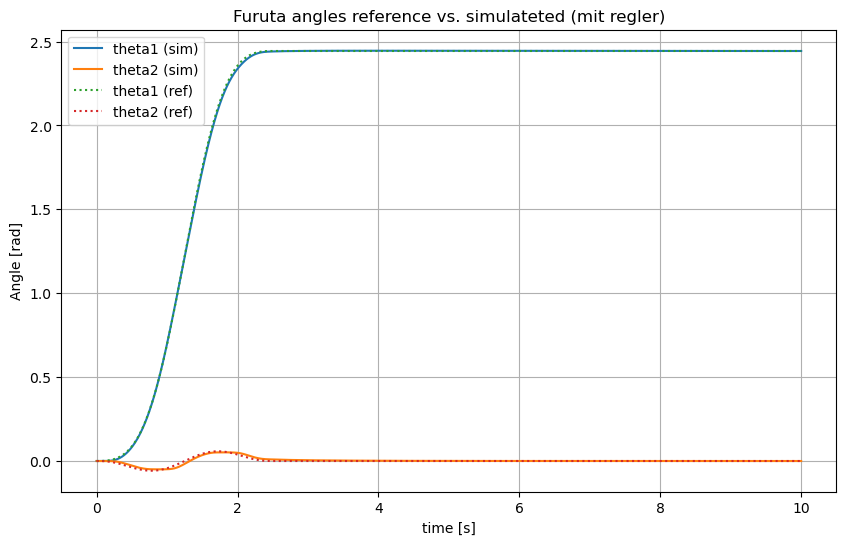

In [6]:
#plot sim angles
theta1_sim = sol.y[0]
theta2_sim = sol.y[2]

#plot x_ref
theta1_ref = np.array([x_ref(t)[0] for t in t_sim])
theta2_ref = np.array([x_ref(t)[2] for t in t_sim])

plt.figure(figsize=(10, 6))
plt.plot(t_sim, theta1_sim, label="theta1 (sim)")
plt.plot(t_sim, theta2_sim, label="theta2 (sim)")
plt.plot(t_sim, theta1_ref, label="theta1 (ref)", linestyle=':')
plt.plot(t_sim, theta2_ref, label="theta2 (ref)", linestyle=':')
plt.title("Furuta angles reference vs. simulateted (mit regler)")
plt.ylabel("Angle [rad]")
plt.xlabel("time [s]")
plt.legend()
plt.grid(True)
plt.show()